<a href="https://colab.research.google.com/github/Osujan/MLTSA25_SShrestha/blob/main/HW7/autoencoder_time_series_instructions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder for time series
an autoencoder is a deep neural network that reproduces input data

it does so by progressively shrinking the size of the layers from the input size to a bottle neck and then expanding them back progressively to the initial size

note: the input and target are the same!

put your imports in the top cell

In [ ]:
#Deep leaarning imports
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
import glob
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as pl


get the data by cloaning the repo https://github.com/nlandolfi/acc2022treelinearcascades_stocks.git

In [ ]:
!git clone https://github.com/nlandolfi/acc2022treelinearcascades_stocks

fatal: destination path 'acc2022treelinearcascades_stocks' already exists and is not an empty directory.


In [ ]:
ls

acc2022treelinearcascades_stocks/  sample_data/


In [ ]:
ls acc2022treelinearcascades_stocks/data

aapl.csv  cat.csv   dis.csv  ibm.csv   ko.csv   msft.csv  unh.csv  wmt.csv
amgn.csv  crm.csv   gs.csv   intc.csv  mcd.csv  nke.csv   v.csv
axp.csv   csco.csv  hd.csv   jnj.csv   mmm.csv  pg.csv    vz.csv
ba.csv    cvx.csv   hon.csv  jpm.csv   mrk.csv  trv.csv   wba.csv


check that all files have the same length. The system command `wc -l returns` the  number of lines (stands for "word count -lines")

In [ ]:
!wc -l acc2022treelinearcascades_stocks/data/*

   2516 acc2022treelinearcascades_stocks/data/aapl.csv
   2516 acc2022treelinearcascades_stocks/data/amgn.csv
   2516 acc2022treelinearcascades_stocks/data/axp.csv
   2516 acc2022treelinearcascades_stocks/data/ba.csv
   2516 acc2022treelinearcascades_stocks/data/cat.csv
   2516 acc2022treelinearcascades_stocks/data/crm.csv
   2516 acc2022treelinearcascades_stocks/data/csco.csv
   2516 acc2022treelinearcascades_stocks/data/cvx.csv
   2516 acc2022treelinearcascades_stocks/data/dis.csv
   2516 acc2022treelinearcascades_stocks/data/gs.csv
   2516 acc2022treelinearcascades_stocks/data/hd.csv
   2516 acc2022treelinearcascades_stocks/data/hon.csv
   2516 acc2022treelinearcascades_stocks/data/ibm.csv
   2516 acc2022treelinearcascades_stocks/data/intc.csv
   2516 acc2022treelinearcascades_stocks/data/jnj.csv
   2516 acc2022treelinearcascades_stocks/data/jpm.csv
   2516 acc2022treelinearcascades_stocks/data/ko.csv
   2516 acc2022treelinearcascades_stocks/data/mcd.csv
   2516 acc2022treelinearcas

In [ ]:
!rm acc2022treelinearcascades_stocks/data/dow.csv

rm: cannot remove 'acc2022treelinearcascades_stocks/data/dow.csv': No such file or directory


In [ ]:
#create a list of all files you want to load
files = glob.glob("acc2022treelinearcascades_stocks/data/*")

In [ ]:
n_files = len(files)
with open(files[0], 'r') as f:
    n_lines = sum(1 for line in f) -1  # subtract 1 to exclude header row
data = np.zeros((n_files, n_lines))


In [ ]:
data.shape

(29, 2516)

 read in all the data into the array

In [ ]:
# prompt: read in all the data into the array
# for i,f in tqdm(enumerate(files)):
#   ....

from tqdm import tqdm

# Get the minimum number of lines among all files to ensure consistent array dimensions
min_length = float('inf')  # Initialize with infinity
for f in files:
    with open(f, 'r') as file:
        num_lines = sum(1 for line in file) - 1  # Subtract 1 for header
        min_length = min(min_length, num_lines)

# Now, read the data using min_length
for i, f in tqdm(enumerate(files)):
    df = np.genfromtxt(f, delimiter=',', skip_header=1)
    data[i, :] = df[:min_length, 5]  # Assuming the "Volume" column is the 6th (index 5)

29it [00:00, 96.82it/s]


plot the time series

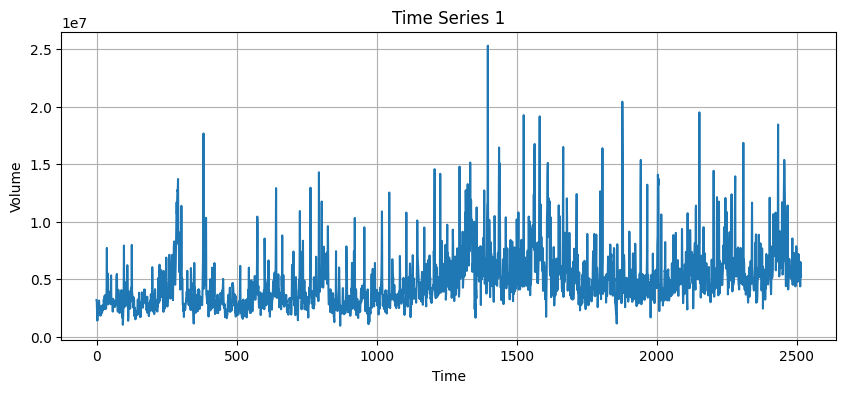

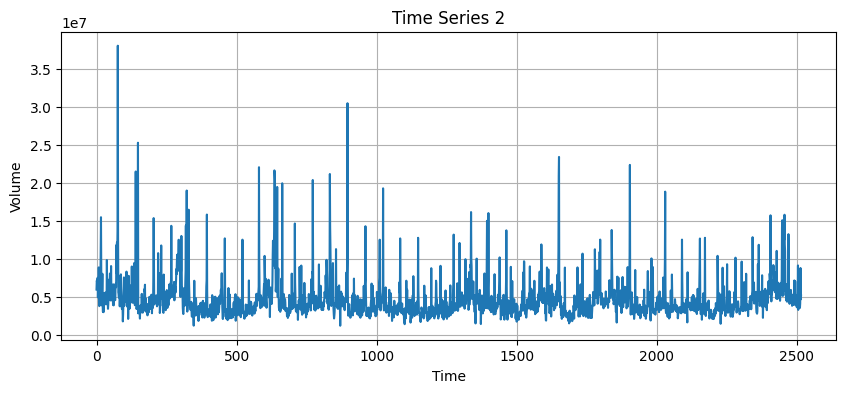

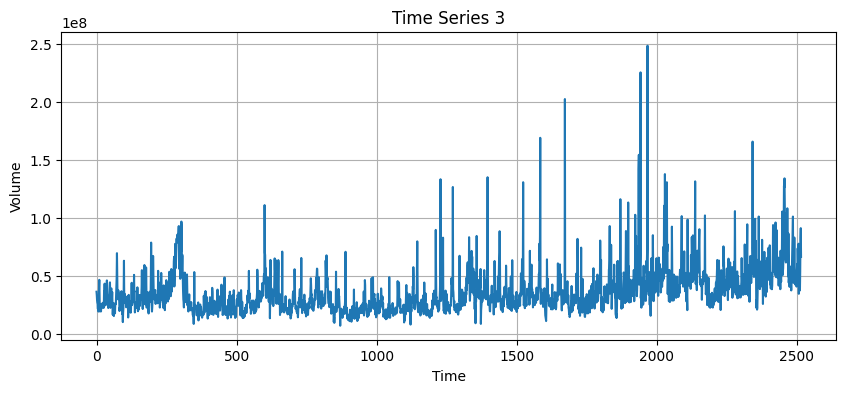

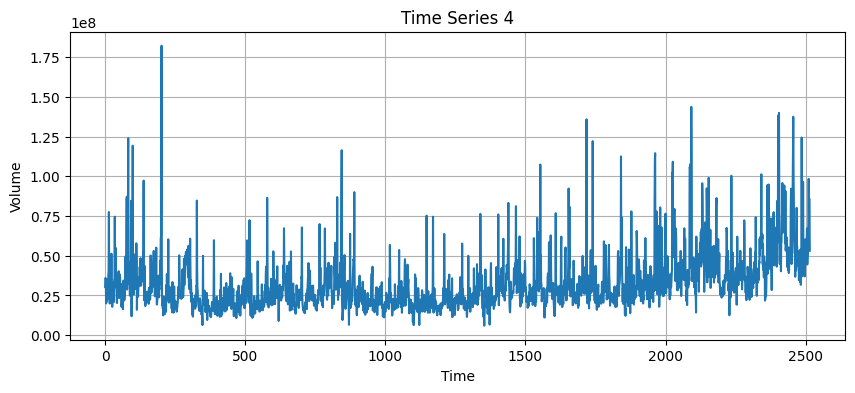

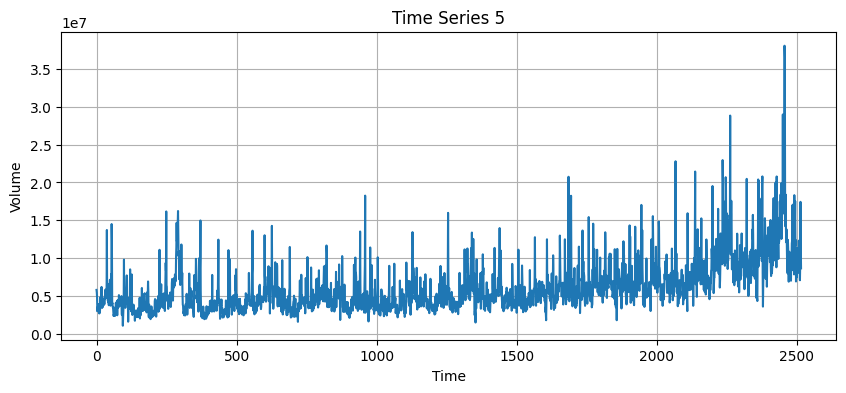

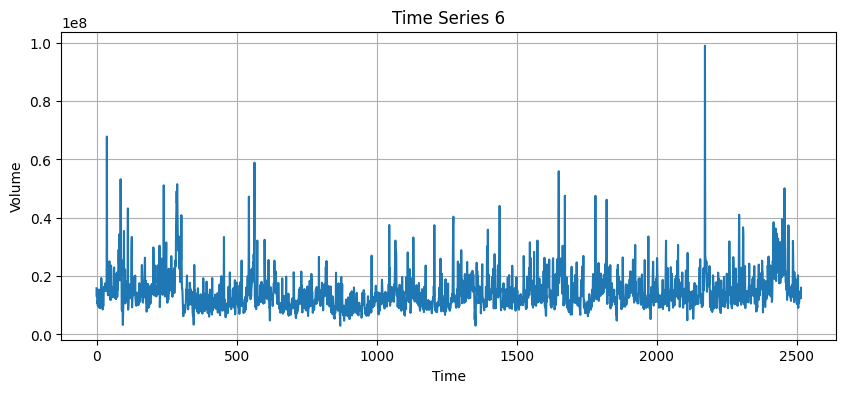

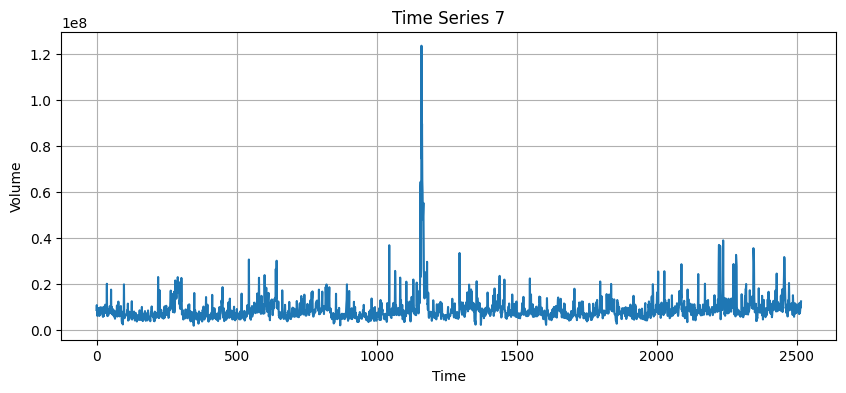

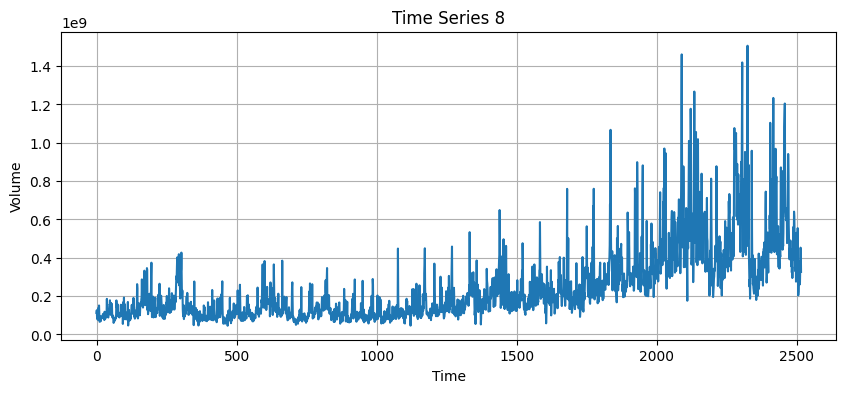

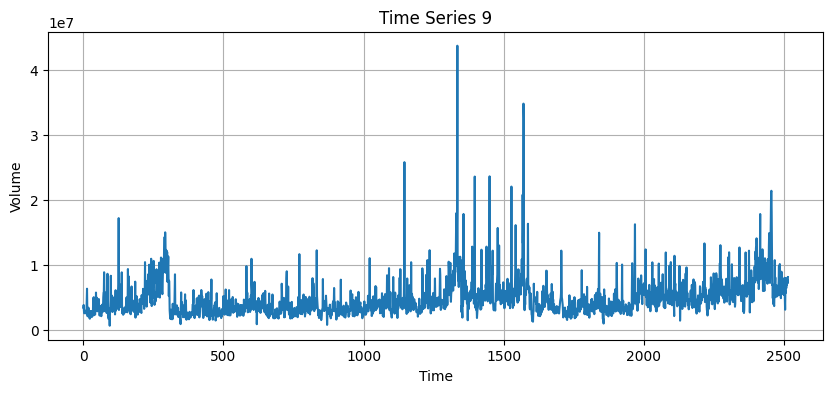

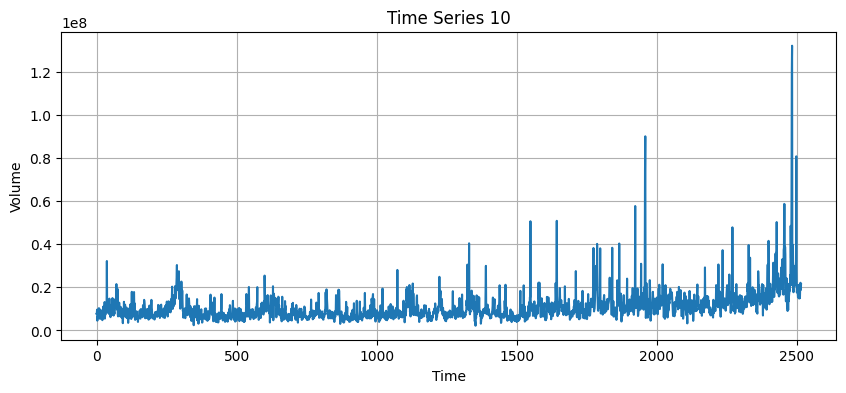

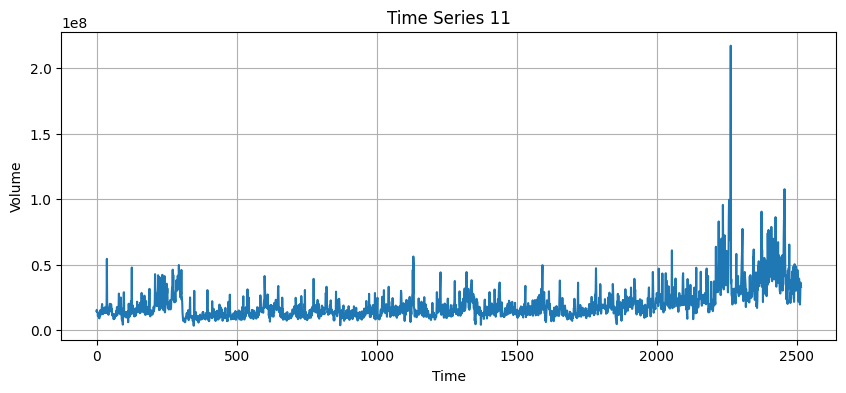

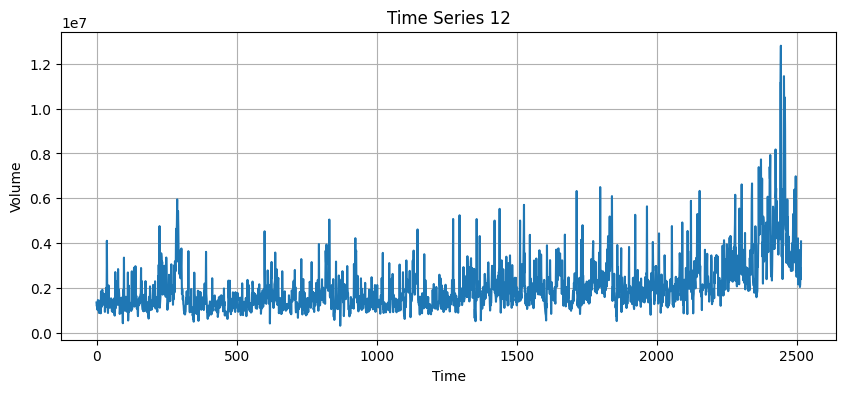

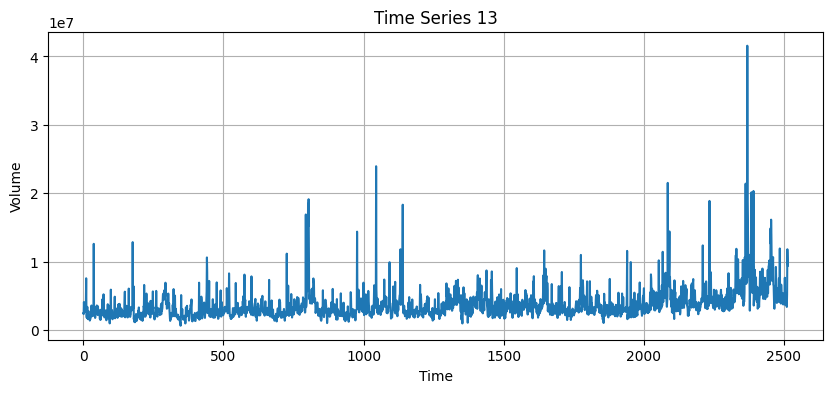

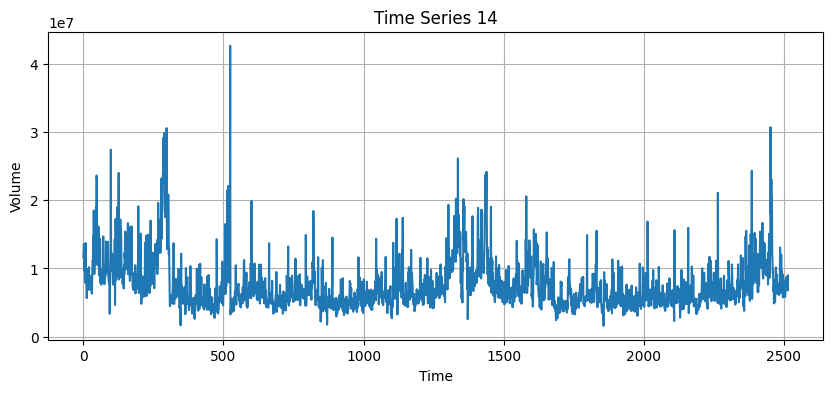

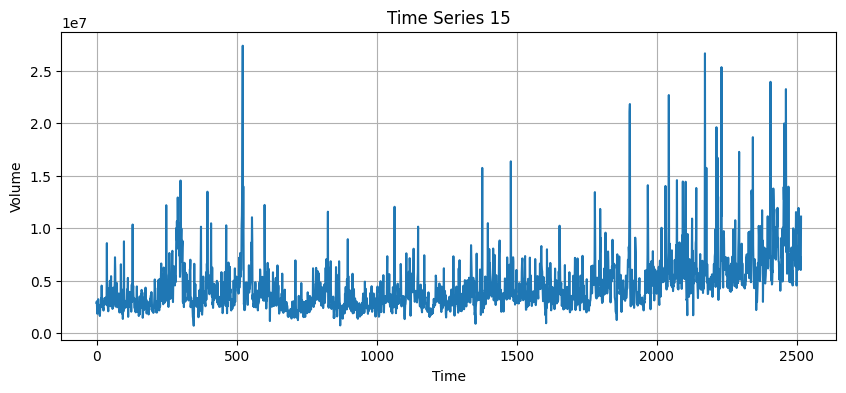

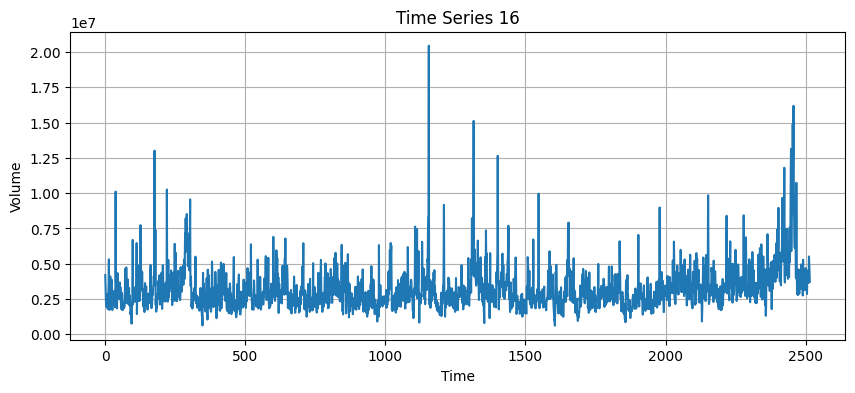

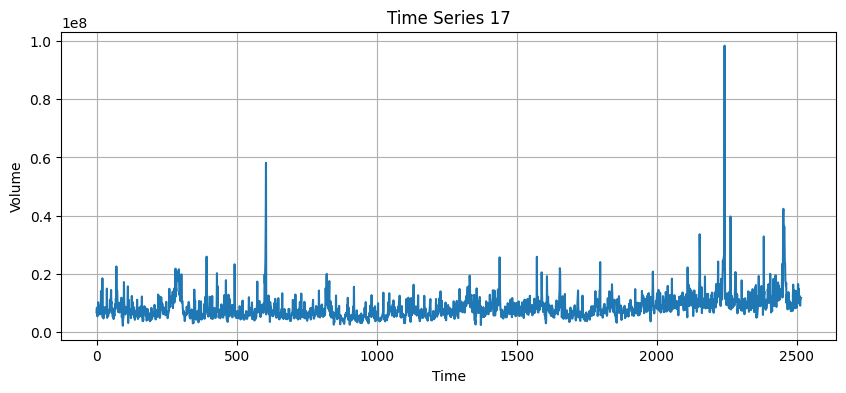

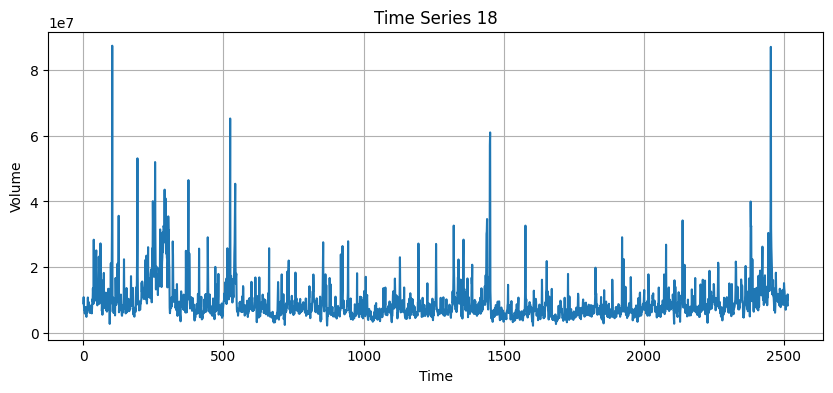

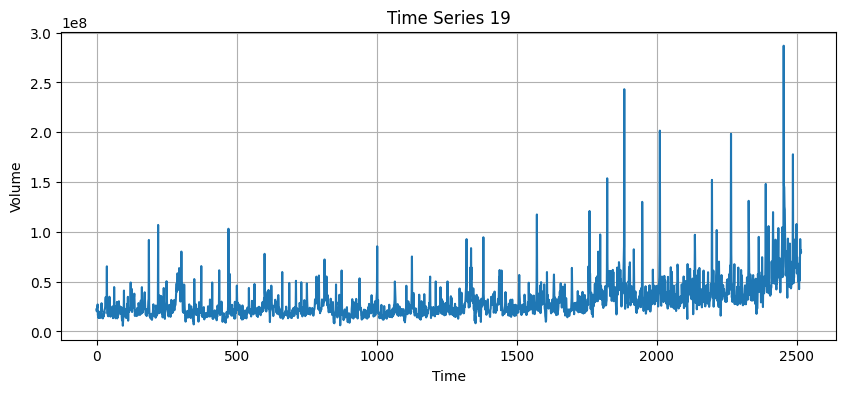

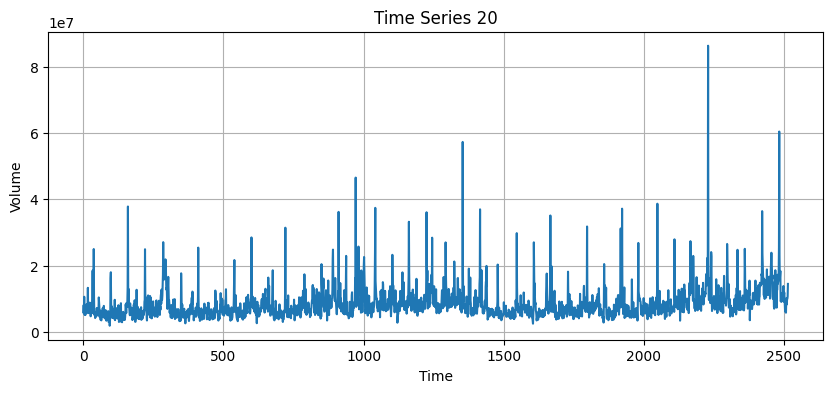

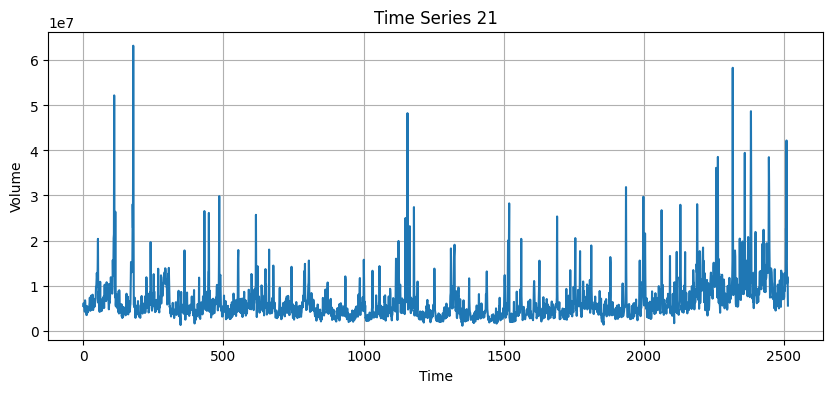

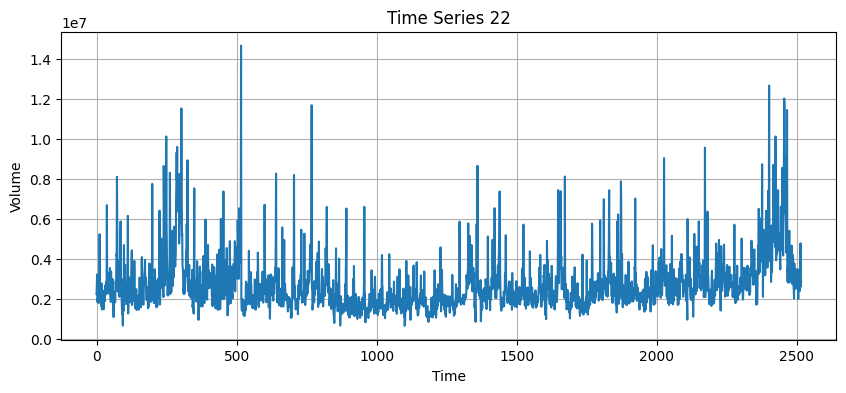

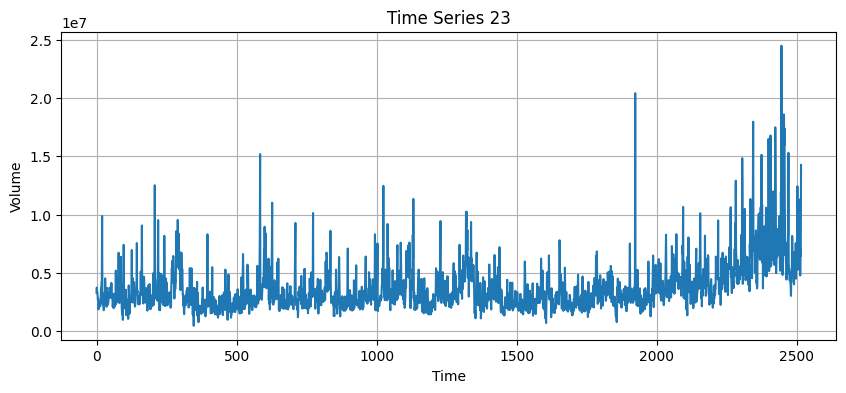

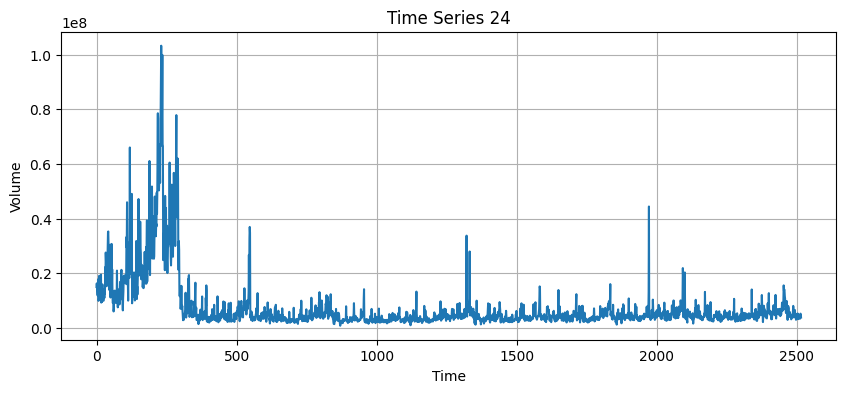

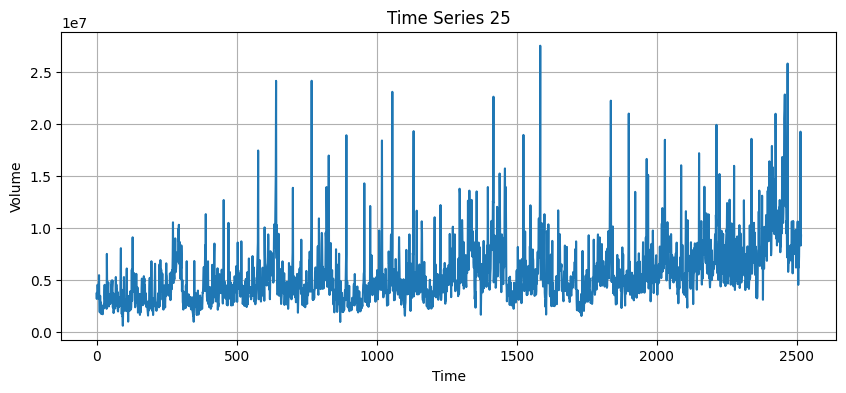

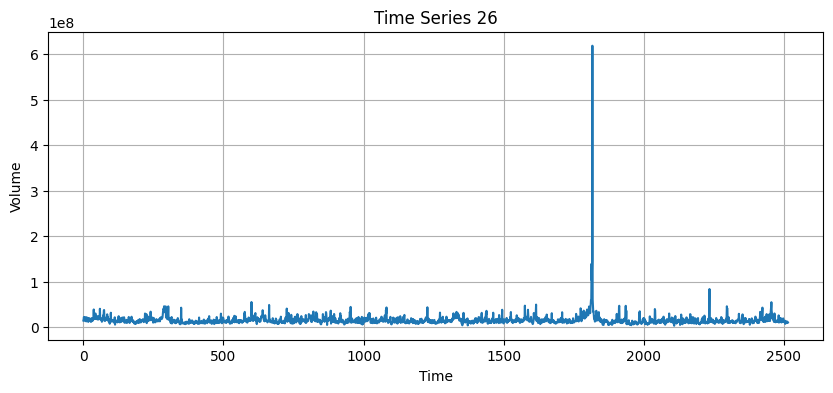

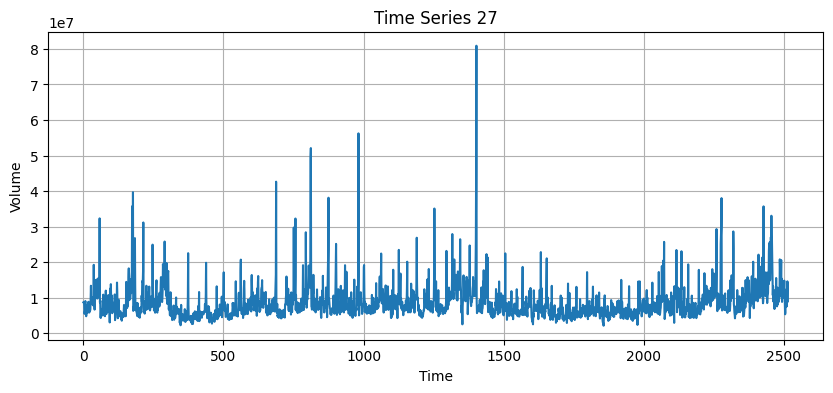

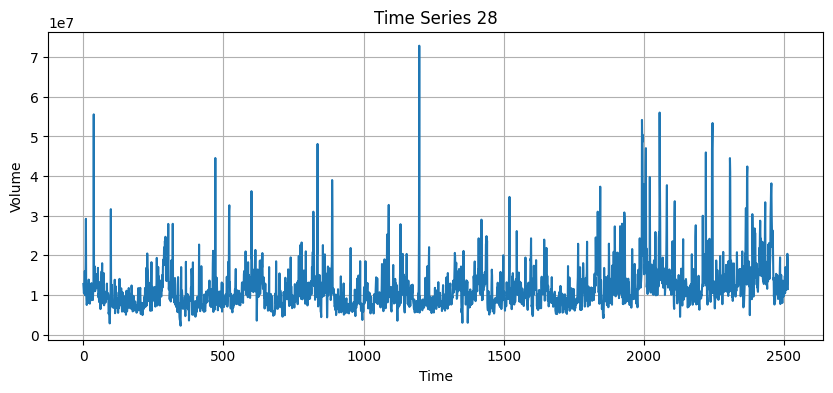

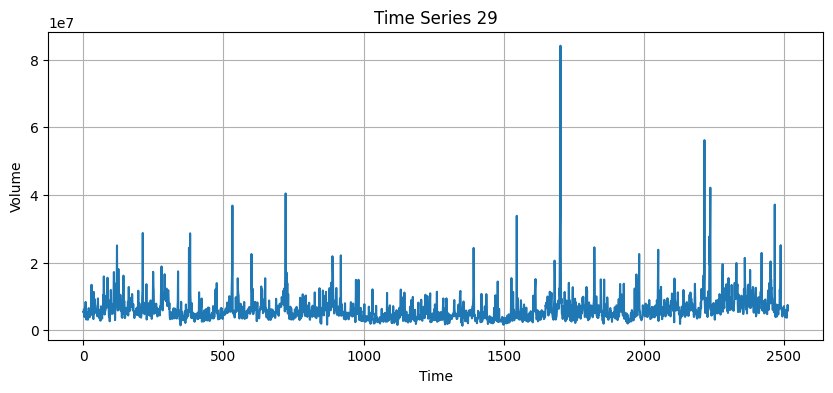

In [ ]:
# prompt: plot the time series




for i in range(data.shape[0]):
    pl.figure(figsize=(10, 4))
    pl.plot(data[i, :])
    pl.title(f"Time Series {i+1}")
    pl.xlabel("Time")
    pl.ylabel("Volume")
    pl.grid(True)
    pl.show()


Figure 1: This figure shows the plots of each time series before normalization. In each of these plots, the horizontal axis represents the time and the vertical axis represents the volume. This allows us to observe the general shape of most of the time series. We see that the time series tend to stay near a certain mean value, with large amounts of noise. In some of the time series the average stays constant throughout, while in others the average changes over time.

scale the time series appropriately
hint: use Standard Scaler to save the mean and standard deviation of each time series, that way you can apply them later to your predicted results

In [ ]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data.T).T
print(scaler.mean_)

[4.83503569e+06 4.64859694e+06 3.61821291e+07 3.23061745e+07
 6.13210239e+06 1.44888552e+07 9.05137382e+06 2.41918808e+08
 4.82569939e+06 1.07715065e+07 1.95325344e+07 2.00906164e+06
 3.68032742e+06 7.59459024e+06 4.47784854e+06 3.20954830e+06
 8.38605635e+06 9.22106420e+06 3.04478866e+07 8.38845291e+06
 6.39931196e+06 2.70803716e+06 3.69958000e+06 7.31825091e+06
 5.49183710e+06 1.57255425e+07 8.56753041e+06 1.16112013e+07
 6.22716013e+06]


In [ ]:
scaled_data.mean(axis=1)

array([-1.35556643e-16,  2.54168705e-17, -1.12963869e-16,  4.51855476e-17,
       -9.03710952e-17,  3.38891607e-17,  5.36578378e-17,  1.35556643e-16,
       -4.51855476e-17, -9.03710952e-17, -9.03710952e-17,  9.03710952e-17,
       -1.12963869e-16,  2.25927738e-17,  1.58149417e-16, -1.12963869e-17,
        9.03710952e-17, -6.21301279e-17, -4.51855476e-17, -6.77783214e-17,
        0.00000000e+00,  1.58149417e-16, -6.77783214e-17,  0.00000000e+00,
       -6.77783214e-17,  7.20144665e-17,  8.47229017e-17, -9.03710952e-17,
        7.90747083e-17])

In [ ]:
scaled_data.std(axis=1)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

split traiing and testimg data

In [ ]:

training_set, test_set = train_test_split(scaled_data, test_size=0.2)
X_train, y_train = training_set, training_set
X_test, y_test = test_set, test_set

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((23, 2516), (6, 2516), (23, 2516), (6, 2516))

build the model. It shoudl be a MLP (Multi Layer Perceptron) thus the only kind of layers you need are Dense layers (`from keras.layers import Dense`). Keep in mind the size of the initial time series. By definition a autoencoder will start with large layers, shdink the number of neurons in each layer progressively till a "bottle neck" layer (e.g. 32 neurons, but try what works). then add progressively larger layers until the last layer has the same size as the imput data. Use `relu` activation functions for all layers but the last one, which shoudl be `linear`

In [ ]:

input_size = scaled_data.shape[1]
model = Sequential()
model.add(Dense(512, activation='relu', input_shape=(input_size,)))
model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu')) # Bottleneck layer
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dense(256, activation='relu'))
model.add(Dense(512, activation='relu'))
model.add(Dense(input_size, activation='linear')) # Output layer with linear activation


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# this is a call back that ensures you stop training when the validation loss stops improving (es)
# ad saves the model if it is better than the model at the previous training epoch (mc)

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=10)
mc = ModelCheckpoint('best_model.h5', monitor='val_loss', mode='min', verbose=1, save_best_only=True)


write the `model.compile` command passing to the compile function the `adam` optimizer and `mean_squared_error` loss function

```model.compile(...```


In [ ]:
# prompt: write the model.compile command passing to the compile function the adam optimizer and mean_squared_error loss function
# model.compile(...

model.compile(optimizer='adam', loss='mean_squared_error')


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     1,288,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2516)           │     1,290,708 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,929,012 (11.17 MB)

 Trainable params: 2,929,012 (11.17 MB)

 Non-trainable params: 0 (0.00 B)

write the model.fit command. This will start the training of the neural network.
pass to the fit() function the following arguments:
- the imput data: that is your data train pd.array
- the desired output.... pay attention! this is an autoencoder so it should reproduce with fidelity the input data!
- create an internal validation set: this will split the training data so that at each epoch you can assess the model performance on unseen data `validation_split=0.1`
- set up training for 200 epochs with the `epoch=200` argument
- set the `batch_size`. I set it to 10, you can try different things. Larger batch makes a faster code the has higher risk of overfitting
- set `verbose=1`
- add the callbacks with `callbacks=[es, mc]


```training = model.fit(.....```



In [ ]:

training = model.fit(X_train, y_train, epochs=200, batch_size=10, validation_split=0.1, verbose=1, callbacks=[es, mc])


Epoch 1/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - loss: 1.0928
Epoch 1: val_loss improved from inf to 0.86346, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - loss: 1.0359 - val_loss: 0.8635
Epoch 2/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - loss: 0.7864
Epoch 2: val_loss improved from 0.86346 to 0.83795, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.7795 - val_loss: 0.8379
Epoch 3/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.7292
Epoch 3: val_loss did not improve from 0.83795
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.7192 - val_loss: 0.8427
Epoch 4/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.6643
Epoch 4: val_loss improved from 0.83795 to 0.81979, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.6871 - val_loss: 0.8198
Epoch 5/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - loss: 0.6885
Epoch 5: val_loss improved from 0.81979 to 0.79187, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - loss: 0.6821 - val_loss: 0.7919
Epoch 6/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.6353
Epoch 6: val_loss improved from 0.79187 to 0.77112, saving model to best_model.h5


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 0.6383 - val_loss: 0.7539
Epoch 15/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.6472
Epoch 15: val_loss improved from 0.75394 to 0.75267, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - loss: 0.6408 - val_loss: 0.7527
Epoch 16/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - loss: 0.6545
Epoch 16: val_loss improved from 0.75267 to 0.75152, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 0.6430 - val_loss: 0.7515
Epoch 17/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - loss: 0.6086
Epoch 17: val_loss did not improve from 0.75152
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.6276 - val_loss: 0.7533
Epoch 18/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.6505
Epoch 18: val_loss did not improve from 0.75152
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.6410 - val_loss: 0.7542
Epoch 19/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.6298
Epoch 19: val_loss did not improve from 0.75152
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6341 - val_loss: 0.7550
Epoch 20/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.5868
Epoch 20: val_loss did not improve from 0.75152
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.6198 - val_loss: 0.7554
Epoch 21/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6389
Epoch 21: val_loss did not improve from 0.75152
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 0.6368 - val_loss: 0.7

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.6265 - val_loss: 0.7512
Epoch 24/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.5940
Epoch 24: val_loss did not improve from 0.75119
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.6213 - val_loss: 0.7517
Epoch 25/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.7144
Epoch 25: val_loss improved from 0.75119 to 0.74994, saving model to best_model.h5


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.6622 - val_loss: 0.7499
Epoch 26/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - loss: 0.6228
Epoch 26: val_loss did not improve from 0.74994
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.6310 - val_loss: 0.7521
Epoch 27/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.6338
Epoch 27: val_loss did not improve from 0.74994
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.6348 - val_loss: 0.7544
Epoch 28/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.6104
Epoch 28: val_loss did not improve from 0.74994
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.6270 - val_loss: 0.7539
Epoch 29/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.5901
Epoch 29: val_loss did not improve from 0.74994
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.6202 - val_loss: 0.7541
Epoch 30/200
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.6265
Epoch 30: val_loss did not improve from 0.74994
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.6322 - val_loss: 

In [ ]:
training.history.keys() # this stores the value of the loss at each epoch so you can plot it

dict_keys(['loss', 'val_loss'])

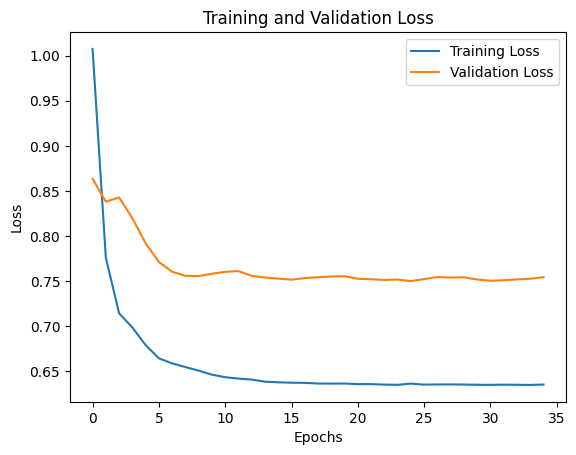

In [ ]:
import matplotlib.pyplot as plt # import the library

plt.plot(training.history['loss'])
plt.plot(training.history['val_loss']);
# add axis labels and legend!!
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Training Loss', 'Validation Loss'])
plt.title('Training and Validation Loss')
plt.show()

Figure 2: The model loss as a function of epoch for both the training and the validation data. The training loss drops sharply at the begining but becomes stable after epoch 10. The validation model loss stays around .75.

plot (visualize) the prediction and the ground truth for the test data. What do you see? where is the model succesful where is it not?

In [ ]:
prediction = model.predict(X_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [ ]:
prediction.shape

(6, 2516)

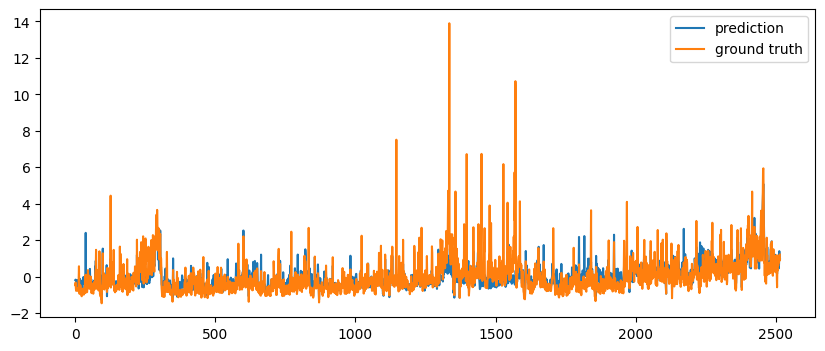

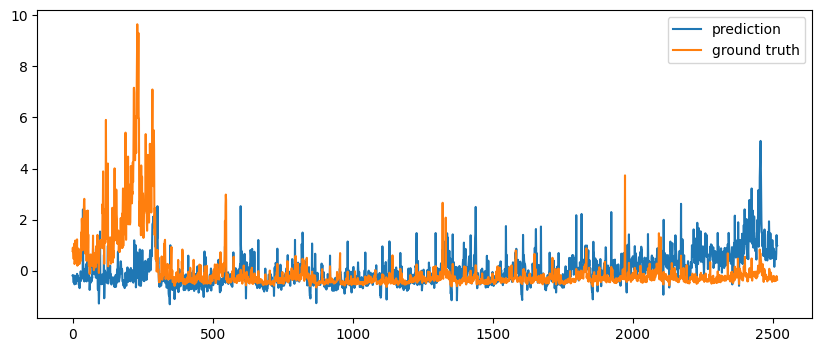

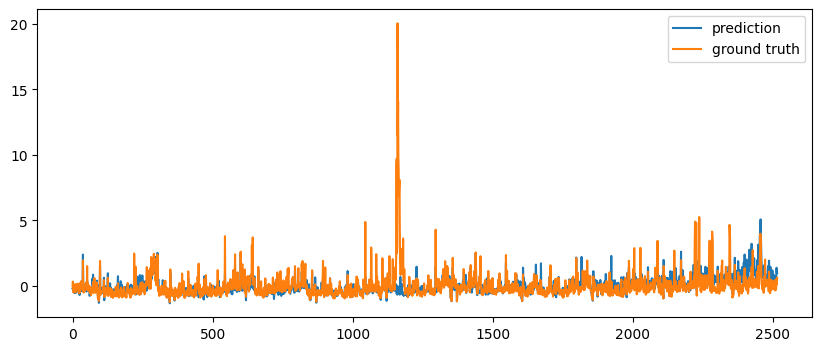

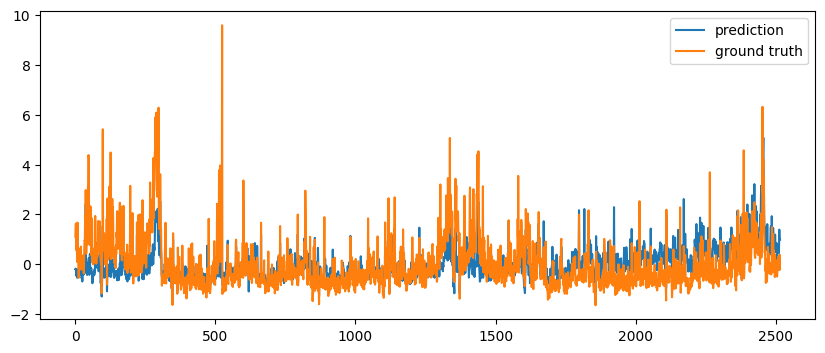

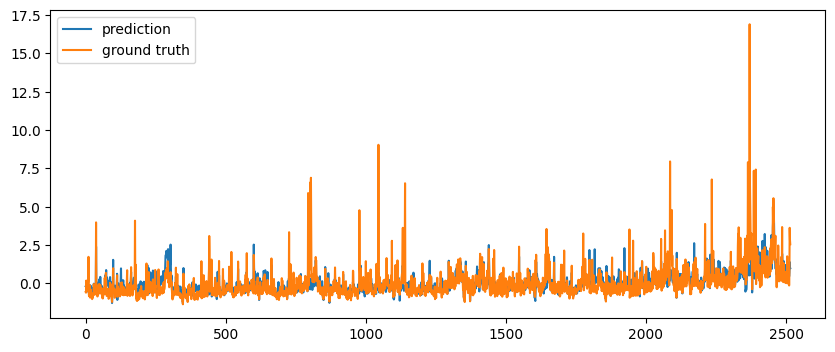

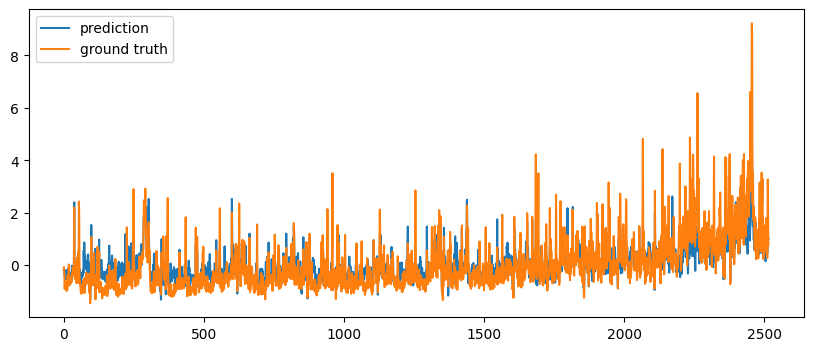

In [ ]:
for i,_ in enumerate(X_test):
  pl.figure(figsize=(10, 4))
  pl.plot(prediction[i], label = 'prediction')
  pl.plot(X_test[i], label = 'ground truth', linestyle = '-')
  pl.legend()
  pl.show()

Figure 3: This figure shows both the prediction and the ground truth for each of the time series in the testing set. In each plot, the prediction is shown in blue while the ground truth is shown in orange. The prediction is good at mimicking the main trend and overall shapes of the data.

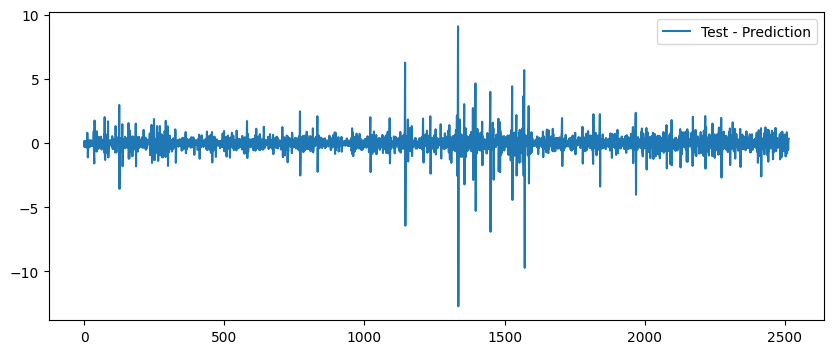

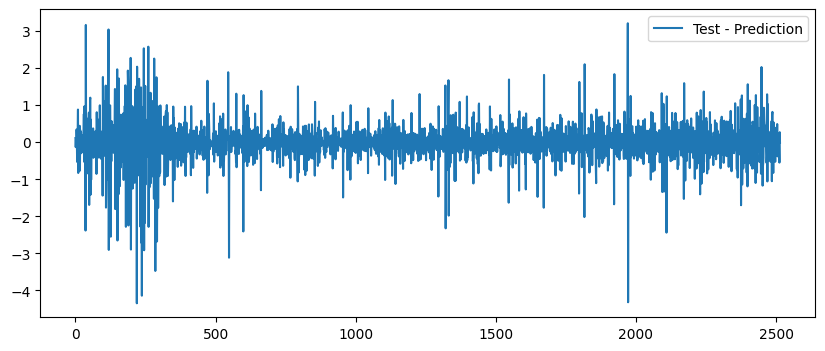

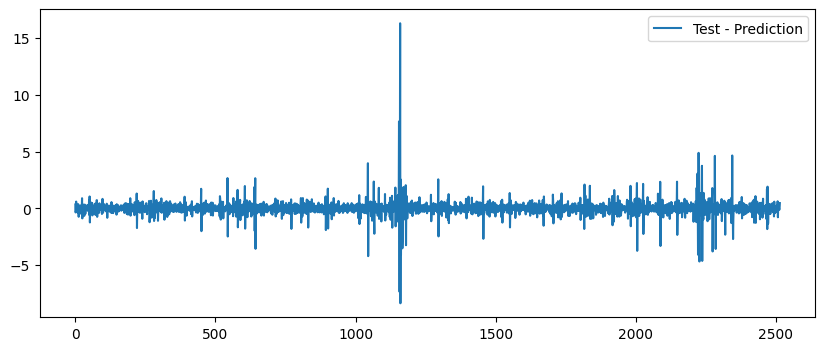

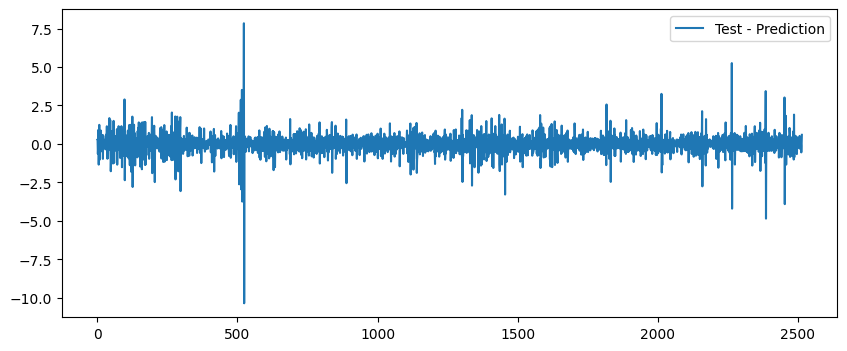

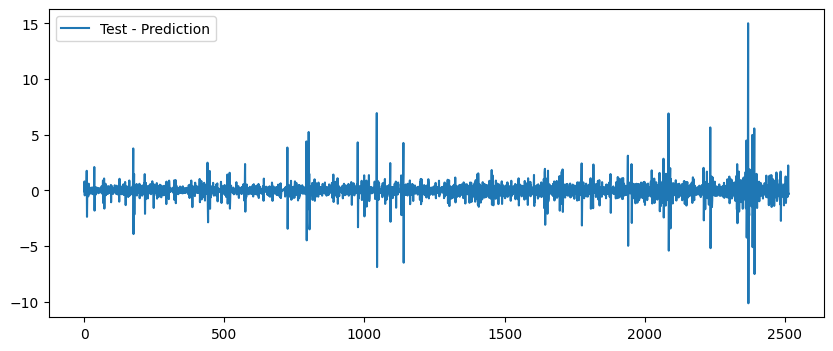

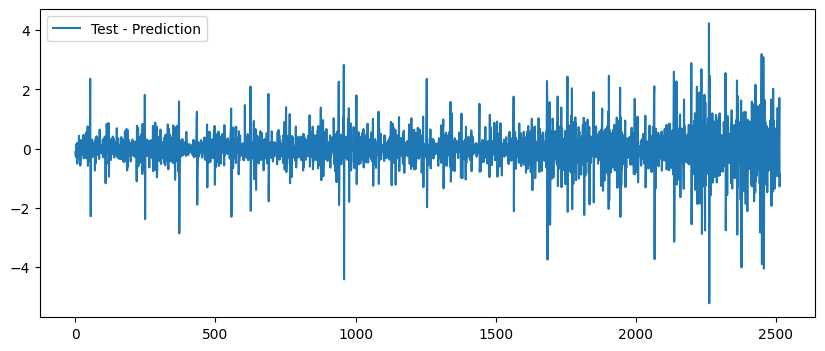

In [ ]:
for i,_ in enumerate(X_test):
  pl.figure(figsize=(10, 4))
  pl.plot(np.diff(X_test[i]-prediction[i]), label = 'Test - Prediction')
  #pl.plot(X_test[i], label = 'ground truth', linestyle = '-')
  pl.legend()
  pl.show()

Figure 4: The plots show the difference between the predicted and actual stock prices (test minus prediction). Fluctuations are present, with the prediction sometimes higher and sometimes lower than the actual value. Some differences remain relatively constant over time, while others increase. Notably, the model struggles to capture a sharp peak in one stock price, indicating a poor fit for that specific behavior. The varying differences across stocks suggest the model may have difficulty fitting all datasets simultaneously, potentially due to overfitting the training data or needing more specialized approaches for different stocks